In [1]:
import copy
import logging
import numpy as np
import pandas as pd
import pyXLMS
from pyXLMS_adaptor import read
from mokapot_rescore import rescore
from post_process import group_by_residue_pair  # noqa: F401
import matplotlib.pyplot as plt
import seaborn as sns

from typing import Tuple

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

DTYPE_CSM = "crosslink-spectrum-matches"
SPECTRONAUT_TRUE = [753, 793, 680]
SPECTRONAUT_FALSE = [0, 0, 0]
SAVE_OUTPUTS = False

In [2]:
from IPython.core.magic import register_cell_magic


@register_cell_magic
def skip(line, cell):
    return

In [3]:
%%skip

df = pd.read_csv(
    "../data/THIDDIAXL003_Cas9_PhoX_DIA12_CeleEntrap_100per_LibSizeTest_SN20c4_Report_FM_crosslinking_plusDecoy (Normal).tsv_annotated.csv.xz",
    compression="xz",
    low_memory=False,
)

In [4]:
%%skip

df = group_by_residue_pair(df)
df.to_csv("../data/entrapment_grouped.csv", index=False)

In [5]:
df = pd.read_csv("../data/entrapment_grouped.csv", low_memory=False)

In [6]:
rep1, rep2, rep3 = tuple(sorted(df["R.FileName"].value_counts().index.tolist()))
print(f"{rep1}\n{rep2}\n{rep3}")

20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_001
20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_002
20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAXL003_Cas9_PhoX_DIA12_CV486075_250ng_FAIMS_003


In [7]:
df_rep1 = df[df["R.FileName"] == rep1].copy()
df_rep2 = df[df["R.FileName"] == rep2].copy()
df_rep3 = df[df["R.FileName"] == rep3].copy()

In [8]:
print(f"Number of CSMs with missing organism label: {sum(df['PG.Organisms'].isna())}")

Number of CSMs with missing organism label: 1


In [9]:
df["PG.Organisms"].value_counts()

PG.Organisms
S pyogenes    14492
Celegans       3395
Name: count, dtype: int64

In [10]:
spyo = df[df["PG.Organisms"] == "S pyogenes"]
cele = df[df["PG.Organisms"] == "Celegans"]

In [11]:
csms = read(df, "EG.Cscore")[DTYPE_CSM]
csms_rep1 = read(df_rep1, "EG.Cscore")[DTYPE_CSM]
csms_rep2 = read(df_rep2, "EG.Cscore")[DTYPE_CSM]
csms_rep3 = read(df_rep3, "EG.Cscore")[DTYPE_CSM]
spyo_csms = read(spyo, "EG.Cscore")[DTYPE_CSM]
cele_csms = read(cele, "EG.Cscore")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 3395/3395 [00:01<00:00, 3001.08it/s]


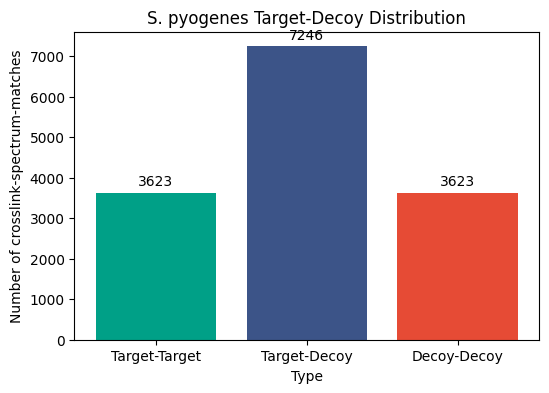

In [12]:
pyXLMS.plotting.plot_target_decoy_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Distribution",
    filename_prefix=None,
);

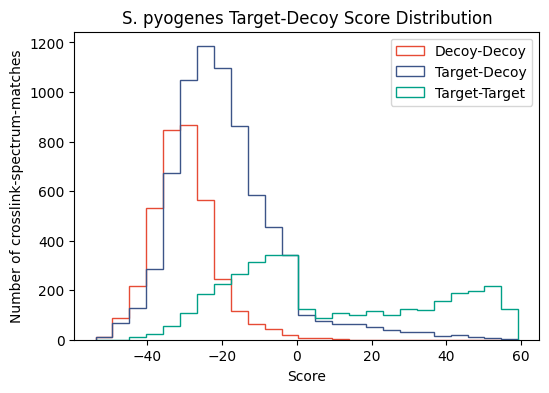

In [13]:
pyXLMS.plotting.plot_score_distribution(
    spyo_csms,
    figsize=(6, 4),
    title="S. pyogenes Target-Decoy Score Distribution",
    filename_prefix=None,
);

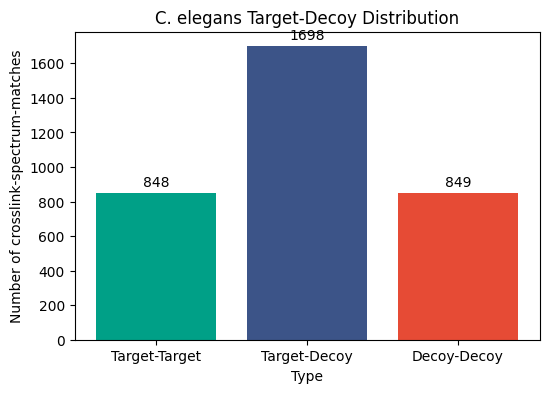

In [14]:
pyXLMS.plotting.plot_target_decoy_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Distribution",
    filename_prefix=None,
);

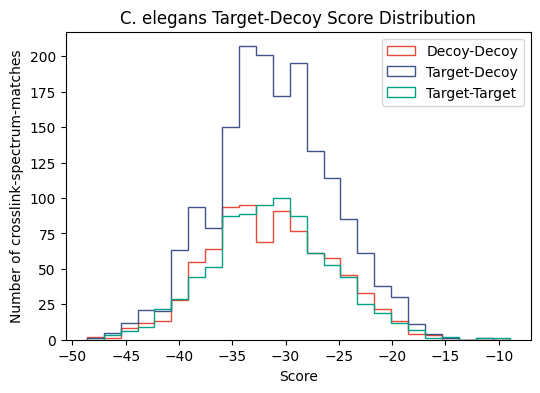

In [15]:
pyXLMS.plotting.plot_score_distribution(
    cele_csms,
    figsize=(6, 4),
    title="C. elegans Target-Decoy Score Distribution",
    filename_prefix=None,
);

## **Mokapot Rescoring**

Please note that Mokapot outputs are not exactly reproducible even with our best efforts to set all random seeds to constants. Outputs still show slight variations even though inputs are exactly the same. For reproducibility, our Mokapot results have been saved in `results`.

In [16]:
rlcsm_rep1 = rescore(df_rep1, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5809 PSMs:
	- Target PSMs: 1390
	- Decoy PSMs: 4419
	- Unique spectra: 5809
	- Unique peptides: 5289
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: No PSMs found below the 'eval_fdr' 0.01 for any feature.

In [17]:
rlcsm_rep1

NameError: name 'rlcsm_rep1' is not defined

In [18]:
rlcsm_rep2 = rescore(df_rep2, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5853 PSMs:
	- Target PSMs: 1291
	- Decoy PSMs: 4562
	- Unique spectra: 5853
	- Unique peptides: 5286
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: No PSMs found below the 'eval_fdr' 0.01 for any feature.

In [19]:
rlcsm_rep2

NameError: name 'rlcsm_rep2' is not defined

In [20]:
rlcsm_rep3 = rescore(df_rep3, level="CSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 6226 PSMs:
	- Target PSMs: 1791
	- Decoy PSMs: 4435
	- Unique spectra: 6226
	- Unique peptides: 5658
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverageFull', 'PP.UniScoreAlpha', 'PP.UniScoreBeta', 'PP.UniScoreFull', 'PP.PepLenAlpha', 'PP.PepLenBeta', 'PP.NumberCrosslinkFragmentsAlpha', 'PP.NumberCrosslinkFragmentsBeta', 'PP.NumberCrosslinkFragmentsFull', 'PP.Normalized

RuntimeError: Failed to calibrate scores between cross-validation folds, because no target PSMs could be found below 'test_fdr'. Try raising 'test_fdr'.

In [21]:
rlcsm_rep3

NameError: name 'rlcsm_rep3' is not defined

In [22]:
rlcsm_rep1 = rescore(df_rep1, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5809 PSMs:
	- Target PSMs: 1390
	- Decoy PSMs: 4419
	- Unique spectra: 5809
	- Unique peptides: 5289
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [23]:
if SAVE_OUTPUTS:
    rlcsm_rep1.to_csv("results/rlcsm_rep1.csv", index=False)
rlcsm_rep1 = pd.read_csv("results/rlcsm_rep1.csv", low_memory=False)

In [24]:
rlcsm_rep1

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,MP.Spectrum,MP.Target,MP.Peptide,MP.Protein,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,0.000000,0.090909,45,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,KEAEEAEKRAEAETKAK,A0A0S4XR43,-1.000000
1,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,0.000000,0.086957,67,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,KEAEEAEKRAKTEAEAK,A0A0S4XR43,-1.000000
2,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,0.222222,0.340000,238,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,GPLLQKFHDSEFRTTLDDTSKR,A0A1C3NSL9,-1.000000
3,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,0.555556,0.297872,431,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,QELAQVQDGFQKVLDGARSVLDKRDK,A0A1N7SYP3,-1.000000
4,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A5E4LWV7_A0A5E4LWV7-1156_1141_Decoy,...,0.500000,0.527778,907,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,IKHEVLEDDHYRIEKNILDR,A0A5E4LWV7,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5804,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_G5EGS8-1380_331,...,0.636364,0.470588,771348,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,EPTTAQESKKNGNQQKKITSLKK,U4PBJ9;G5EGS8,-0.514720
5805,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20,...,0.625000,0.580000,771655,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,KKAHPAIQVLAAKTVVAKPK,U4PBJ9;Q27876,-0.484904
5806,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20_Decoy,...,0.666667,0.568182,771749,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,AALVQIAPHAKKKTVVAKPK,U4PBJ9;Q27876,-1.000000
5807,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20_Decoy,...,0.625000,0.591837,771888,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,AALVQIAPHAKKKTVVAKPK,U4PBJ9;Q27876,-1.000000


In [25]:
rlcsm_rep2 = rescore(df_rep2, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 5853 PSMs:
	- Target PSMs: 1291
	- Decoy PSMs: 4562
	- Unique spectra: 5853
	- Unique peptides: 5286
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [26]:
if SAVE_OUTPUTS:
    rlcsm_rep2.to_csv("results/rlcsm_rep2.csv", index=False)
rlcsm_rep2 = pd.read_csv("results/rlcsm_rep2.csv", low_memory=False)

In [27]:
rlcsm_rep2

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,MP.Spectrum,MP.Target,MP.Peptide,MP.Protein,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A0S4XR43_A0A0S4XR43-742_735,...,0.000000,0.086957,771986,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,KEAEEAEKRAKTEAEAK,A0A0S4XR43,-0.756128
1,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1C3NSL9_A0A1C3NSL9-1058_1038,...,0.222222,0.340000,772076,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,GPLLQKFHDSEFRKSTDDLTTR,A0A1C3NSL9,-0.725761
2,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,0.222222,0.346939,772126,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,FESDHFKQLLPGRKSTDDLTTR,A0A1C3NSL9,-1.000000
3,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1N7SYP3_A0A1N7SYP3-2570_2559,...,0.600000,0.312500,772274,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,AGDLVKQFGDQVQALEQRDRKDLVSK,A0A1N7SYP3,-0.869552
4,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A486WXG9_A0A486WXG9-35_40_Decoy,...,0.428571,0.500000,772556,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,GLTKPTQSTVSTAAQSRAPTTTQKKK,A0A486WXG9,-1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5848,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_G5EGS8-1380_331_Decoy,...,0.636364,0.469697,1543466,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,QQNGNKKSEQATTPEKKITSLKK,U4PBJ9;G5EGS8,-1.000000
5849,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_G5EGS8-1380_331_Decoy,...,0.555556,0.435484,1543532,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,QQNGNKKSEQATTPEKKLSTIKK,U4PBJ9;G5EGS8,-1.000000
5850,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_Q27876-1258_20,...,0.666667,0.531915,1543594,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,KKAHPAIQVLAAKTVVAKPK,U4PBJ9;Q27876,-0.484904
5851,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_Q27876-1258_20_Decoy,...,0.666667,0.568182,1543691,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,AALVQIAPHAKKKPKAVVTK,U4PBJ9;Q27876,-1.000000


In [28]:
rlcsm_rep3 = rescore(df_rep3, level="CSM", use_p_and_q_values=True)

INFO:mokapot_rescore:Removed the following features because of missing values: PG.Cscore, EG.GlobalPrecursorQvalue, EG.MaxChannelQvalue, EG.MinChannelQvalue, EG.Qvalue, EG.InSourceFragmentationParentQvalue, EG.AvgProfileQvalue, EG.MaxProfileQvalue, EG.MinProfileQvalue, EG.PercentileQvalue, FG.Qvalue
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 6226 PSMs:
	- Target PSMs: 1791
	- Decoy PSMs: 4435
	- Unique spectra: 6226
	- Unique peptides: 5658
	- Features: ('EG.Cscore', 'FG.Charge', 'PP.MatchedIonsA', 'PP.TotalIonsA', 'PP.MatchedIonsB', 'PP.TotalIonsB', 'PP.RelativeMatchScoreA', 'PP.RelativeMatchScoreB', 'PP.PartialCscoreA', 'PP.PartialCscoreB', 'PP.CompositeRelativeMatchScore', 'PP.CompositePartialCscore', 'PP.SequenceCoverageNTermAlpha', 'PP.SequenceCoverageNTermBeta', 'PP.SequenceCoverageNTermFull', 'PP.SequenceCoverageCTermAlpha', 'PP.SequenceCoverageCTermBeta', 'PP.SequenceCoverageCTermFull', 'PP.SequenceCoverageAlpha', 'PP.SequenceCoverageBeta', 'PP.SequenceCoverag

In [29]:
if SAVE_OUTPUTS:
    rlcsm_rep3.to_csv("results/rlcsm_rep3.csv", index=False)
rlcsm_rep3 = pd.read_csv("results/rlcsm_rep3.csv", low_memory=False)

In [30]:
rlcsm_rep3

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,MP.Spectrum,MP.Target,MP.Peptide,MP.Protein,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,0.000000,0.090909,1543995,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,KEAEEAEKRAEAETKAK,A0A0S4XR43,-1.000000
1,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,0.222222,0.346939,1544161,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,FESDHFKQLLPGRTTLDDTSKR,A0A1C3NSL9,-1.000000
2,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,0.555556,0.297872,1544308,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,AGDLVKQFGDQVQALEQRSVLDKRDK,A0A1N7SYP3,-1.000000
3,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,0.600000,0.312500,1544355,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,QELAQVQDGFQKVLDGARDRKDLVSK,A0A1N7SYP3,-1.000000
4,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A486WXG9_A0A486WXG9-35_40,...,0.478261,0.510870,1544450,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,SQAATSVTSQTPKTLGRKKQTTTPAK,A0A486WXG9,-0.875586
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6221,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147,...,0.357143,0.318182,2314861,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,True,KPENPYIGAKTPLNPQERNEKLTESLK,Q9XXN2,-0.910999
6222,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,0.357143,0.318182,2315188,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,EQPNLPTKAGIYPNEPKRLSETLKENK,Q9XXN2,-1.000000
6223,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,0.357143,0.318182,2315232,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,EQPNLPTKAGIYPNEPKRNEKLTESLK,Q9XXN2,-1.000000
6224,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,0.357143,0.318182,2315276,PhoX,209.97181,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,False,KPENPYIGAKTPLNPQERLSETLKENK,Q9XXN2,-1.000000


In [31]:
rlcsm_csms = dict()
rlcsm_csms["rep1"] = read(rlcsm_rep1, score="Mokapot Score")[DTYPE_CSM]
rlcsm_csms["rep2"] = read(rlcsm_rep2, score="Mokapot Score")[DTYPE_CSM]
rlcsm_csms["rep3"] = read(rlcsm_rep3, score="Mokapot Score")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 6226/6226 [00:02<00:00, 2668.94it/s]


In [32]:
rlpsm_rep1 = rescore(df_rep1, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 11618 PSMs:
	- Target PSMs: 5747
	- Decoy PSMs: 5871
	- Unique spectra: 11618
	- Unique peptides: 1460
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 11618 total PSMs.
INFO:mokapot.brew:  - 5747 target PSMs and 5871 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 334 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [33]:
if SAVE_OUTPUTS:
    rlpsm_rep1.to_csv("results/rlpsm_rep1.csv", index=False)
rlpsm_rep1 = pd.read_csv("results/rlpsm_rep1.csv", low_memory=False)

In [34]:
rlpsm_rep1

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NumberCrosslinkFragmentsFull,PP.NormalizedCrosslinkFragmentsAlpha,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,Mokapot Score Alpha,Mokapot Score Beta,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,2,0.133333,0.000000,0.090909,45,PhoX,209.97181,-0.926197,-0.842972,-0.926197
1,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,2,0.133333,0.000000,0.086957,67,PhoX,209.97181,-0.443949,-0.707705,-0.707705
2,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,17,0.406250,0.222222,0.340000,238,PhoX,209.97181,-0.619940,-0.329892,-0.619940
3,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,14,0.236842,0.555556,0.297872,431,PhoX,209.97181,-0.481125,-0.947801,-0.947801
4,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,A0A5E4LWV7_A0A5E4LWV7-1156_1141_Decoy,...,19,0.541667,0.500000,0.527778,907,PhoX,209.97181,-1.232055,-0.983673,-1.232055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5804,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_G5EGS8-1380_331,...,32,0.391304,0.636364,0.470588,771348,PhoX,209.97181,-0.352684,-0.708877,-0.708877
5805,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20,...,29,0.558824,0.625000,0.580000,771655,PhoX,209.97181,-0.532721,-0.906229,-0.906229
5806,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20_Decoy,...,25,0.531250,0.666667,0.568182,771749,PhoX,209.97181,-0.858358,-1.231846,-1.231846
5807,0,MaxLFQ,0,DIA12_486075,NaN,1,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6061288170810,U4PBJ9_Q27876-1258_20_Decoy,...,29,0.575758,0.625000,0.591837,771888,PhoX,209.97181,-0.639965,-0.803700,-0.803700


In [35]:
rlpsm_rep2 = rescore(df_rep2, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 11706 PSMs:
	- Target PSMs: 5563
	- Decoy PSMs: 6143
	- Unique spectra: 11706
	- Unique peptides: 1375
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 11706 total PSMs.
INFO:mokapot.brew:  - 5563 target PSMs and 6143 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 355 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [36]:
if SAVE_OUTPUTS:
    rlpsm_rep2.to_csv("results/rlpsm_rep2.csv", index=False)
rlpsm_rep2 = pd.read_csv("results/rlpsm_rep2.csv", low_memory=False)

In [37]:
rlpsm_rep2

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NumberCrosslinkFragmentsFull,PP.NormalizedCrosslinkFragmentsAlpha,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,Mokapot Score Alpha,Mokapot Score Beta,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A0S4XR43_A0A0S4XR43-742_735,...,2,0.133333,0.000000,0.086957,771986,PhoX,209.97181,-0.577386,-0.675417,-0.675417
1,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1C3NSL9_A0A1C3NSL9-1058_1038,...,17,0.406250,0.222222,0.340000,772076,PhoX,209.97181,-0.665568,-0.560727,-0.665568
2,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,17,0.419355,0.222222,0.346939,772126,PhoX,209.97181,-0.678846,-0.355286,-0.678846
3,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A1N7SYP3_A0A1N7SYP3-2570_2559,...,15,0.236842,0.600000,0.312500,772274,PhoX,209.97181,-0.595239,-1.113446,-1.113446
4,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,A0A486WXG9_A0A486WXG9-35_40_Decoy,...,43,0.523077,0.428571,0.500000,772556,PhoX,209.97181,-0.923342,-0.571521,-0.923342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5848,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_G5EGS8-1380_331_Decoy,...,31,0.386364,0.636364,0.469697,1543466,PhoX,209.97181,-0.608789,-0.925964,-0.925964
5849,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_G5EGS8-1380_331_Decoy,...,27,0.386364,0.555556,0.435484,1543532,PhoX,209.97181,-0.509799,-0.628260,-0.628260
5850,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_Q27876-1258_20,...,25,0.485714,0.666667,0.531915,1543594,PhoX,209.97181,-0.949188,-1.163796,-1.163796
5851,0,MaxLFQ,0,DIA12_486075,NaN,2,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,6094224068057,U4PBJ9_Q27876-1258_20_Decoy,...,25,0.531250,0.666667,0.568182,1543691,PhoX,209.97181,-0.815278,-1.125804,-1.125804


In [38]:
rlpsm_rep3 = rescore(df_rep3, level="PSM")

INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:Removed the following features because of missing values: 
INFO:mokapot_rescore:A mokapot.dataset.LinearPsmDataset with 12452 PSMs:
	- Target PSMs: 6578
	- Decoy PSMs: 5874
	- Unique spectra: 12452
	- Unique peptides: 1322
	- Features: ('EG.Cscore', 'PP.MatchedIons', 'PP.TotalIons', 'PP.RelativeMatchScore', 'PP.PartialCscore', 'PP.SequenceCoverageNTerm', 'PP.SequenceCoverageCTerm', 'PP.SequenceCoverage', 'PP.UniScore', 'PP.PepLen', 'PP.NumberCrosslinkFragments', 'PP.NormalizedCrosslinkFragments')
INFO:mokapot.brew:Found 12452 total PSMs.
INFO:mokapot.brew:  - 6578 target PSMs and 5874 decoy PSMs detected.
INFO:mokapot.brew:Splitting PSMs into 3 folds...
INFO:mokapot.model:	- Selected feature 'PP.PartialCscore' with 555 PSMs at q<=0.01.
INFO:mokapot.model:Beginning training loop...
INFO:mokapot.model:Done tra

In [39]:
if SAVE_OUTPUTS:
    rlpsm_rep3.to_csv("results/rlpsm_rep3.csv", index=False)
rlpsm_rep3 = pd.read_csv("results/rlpsm_rep3.csv", low_memory=False)

In [40]:
rlpsm_rep3

,E.Errors,E.LFQMethod,E.Warnings,R.Condition,R.Fraction,R.Replicate,R.FileName,R.Label,R.TotalIonCurrent (MS1),PG.GroupLabel,...,PP.NumberCrosslinkFragmentsFull,PP.NormalizedCrosslinkFragmentsAlpha,PP.NormalizedCrosslinkFragmentsBeta,PP.NormalizedCrosslinkFragmentsFull,PP.PseudoScanNumber,PP.Crosslinker,PP.CrosslinkerMass,Mokapot Score Alpha,Mokapot Score Beta,Mokapot Score
0,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A0S4XR43_A0A0S4XR43-742_735_Decoy,...,2,0.133333,0.000000,0.090909,1543995,PhoX,209.97181,-0.661036,-0.755303,-0.755303
1,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1C3NSL9_A0A1C3NSL9-1058_1038_Decoy,...,17,0.419355,0.222222,0.346939,1544161,PhoX,209.97181,-0.419229,-0.225193,-0.419229
2,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,14,0.236842,0.555556,0.297872,1544308,PhoX,209.97181,-0.410156,-1.071131,-1.071131
3,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A1N7SYP3_A0A1N7SYP3-2570_2559_Decoy,...,15,0.236842,0.600000,0.312500,1544355,PhoX,209.97181,-0.460632,-1.183821,-1.183821
4,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,A0A486WXG9_A0A486WXG9-35_40,...,47,0.521739,0.478261,0.510870,1544450,PhoX,209.97181,-0.840201,-0.732063,-0.840201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6221,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147,...,14,0.300000,0.357143,0.318182,2314861,PhoX,209.97181,-0.665910,-0.687560,-0.687560
6222,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,14,0.300000,0.357143,0.318182,2315188,PhoX,209.97181,-0.690051,-0.734025,-0.734025
6223,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,14,0.300000,0.357143,0.318182,2315232,PhoX,209.97181,-0.818249,-0.649739,-0.818249
6224,0,MaxLFQ,0,DIA12_486075,NaN,3,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,20251228_A2_N1_Mueller_MS_TechHub_IMP_THIDDIAX...,5934294936979,Q9XXN2_Q9XXN2-136_147_Decoy,...,14,0.300000,0.357143,0.318182,2315276,PhoX,209.97181,-0.820798,-0.621770,-0.820798


In [41]:
rlpsm_csms = dict()
rlpsm_csms["rep1"] = read(rlpsm_rep1, score="Mokapot Score")[DTYPE_CSM]
rlpsm_csms["rep2"] = read(rlpsm_rep2, score="Mokapot Score")[DTYPE_CSM]
rlpsm_csms["rep3"] = read(rlpsm_rep3, score="Mokapot Score")[DTYPE_CSM]

Reading CSMs...: 100%|███████████████████████████████████████████████████████████| 6226/6226 [00:02<00:00, 2583.53it/s]


In [42]:
def get_urp(csms):
    u = pyXLMS.transform.unique(csms)
    x = pyXLMS.transform.aggregate(u)
    xu = pyXLMS.transform.unique(x, by="protein")
    return xu

In [43]:
def pipeline(csms, fdr: float = 0.01):
    xu = get_urp(csms)
    v = pyXLMS.transform.validate(xu, fdr)
    t = pyXLMS.transform.targets_only(v)
    return t

In [44]:
def get_experimental_fdr(
    csms, true_label="S pyogenes", label_col="PG.Organisms"
) -> Tuple[int, int, float]:
    nr_true = 0
    nr_false = 0
    for csm in csms:
        label = csm["additional_information"]["source"][label_col]
        if label is not None and true_label in label:
            nr_true += 1
        else:
            nr_false += 1
    return nr_true, nr_false, (nr_false / nr_true) * 100.0

### **CSM-level Rescoring**

In [45]:
rlcsm_t = dict()
rlcsm_t["rep1"] = pipeline(rlcsm_csms["rep1"])
rlcsm_t["rep2"] = pipeline(rlcsm_csms["rep2"])
rlcsm_t["rep3"] = pipeline(rlcsm_csms["rep3"])

Iterating over scores for FDR calculation...:  69%|████████████████████         | 2998/4333 [00:00<00:00, 63971.98it/s]


#### Replicate 1

In [46]:
rlcsm_eval1 = get_experimental_fdr(rlcsm_t["rep1"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t['rep1'])};\n"
    f"Number Target Hits: {rlcsm_eval1[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval1[1]};\n"
    f"Experimental FDR: {rlcsm_eval1[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1110;
Number Target Hits: 848;
Number Entrapment Hits: 262;
Experimental FDR: 30.89622641509434%;


#### Replicate 2

In [47]:
rlcsm_eval2 = get_experimental_fdr(rlcsm_t["rep2"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t['rep2'])};\n"
    f"Number Target Hits: {rlcsm_eval2[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval2[1]};\n"
    f"Experimental FDR: {rlcsm_eval2[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1031;
Number Target Hits: 786;
Number Entrapment Hits: 245;
Experimental FDR: 31.170483460559794%;


#### Replicate 3

In [48]:
rlcsm_eval3 = get_experimental_fdr(rlcsm_t["rep3"])
print(
    f"[CSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlcsm_t['rep3'])};\n"
    f"Number Target Hits: {rlcsm_eval3[0]};\n"
    f"Number Entrapment Hits: {rlcsm_eval3[1]};\n"
    f"Experimental FDR: {rlcsm_eval3[2]}%;"
)

[CSM-level Rescoring]
Number of hits at 1% FDR: 1335;
Number Target Hits: 1127;
Number Entrapment Hits: 208;
Experimental FDR: 18.456078083407277%;


### **PSM-level Rescoring**

In [49]:
rlpsm_t = dict()
rlpsm_t["rep1"] = pipeline(rlpsm_csms["rep1"])
rlpsm_t["rep2"] = pipeline(rlpsm_csms["rep2"])
rlpsm_t["rep3"] = pipeline(rlpsm_csms["rep3"])

Iterating over scores for FDR calculation...:  91%|█████████████████████████▌  | 3952/4333 [00:00<00:00, 101633.34it/s]


#### Replicate 1

In [50]:
rlpsm_eval1 = get_experimental_fdr(rlpsm_t["rep1"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t['rep1'])};\n"
    f"Number Target Hits: {rlpsm_eval1[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval1[1]};\n"
    f"Experimental FDR: {rlpsm_eval1[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 254;
Number Target Hits: 254;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


#### Replicate 2

In [51]:
rlpsm_eval2 = get_experimental_fdr(rlpsm_t["rep2"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t['rep2'])};\n"
    f"Number Target Hits: {rlpsm_eval2[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval2[1]};\n"
    f"Experimental FDR: {rlpsm_eval2[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 214;
Number Target Hits: 214;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


#### Replicate 3

In [52]:
rlpsm_eval3 = get_experimental_fdr(rlpsm_t["rep3"])
print(
    f"[PSM-level Rescoring]\nNumber of hits at 1% FDR: {len(rlpsm_t['rep3'])};\n"
    f"Number Target Hits: {rlpsm_eval3[0]};\n"
    f"Number Entrapment Hits: {rlpsm_eval3[1]};\n"
    f"Experimental FDR: {rlpsm_eval3[2]}%;"
)

[PSM-level Rescoring]
Number of hits at 1% FDR: 378;
Number Target Hits: 378;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


### **No Rescoring**

In [53]:
rlnone_t = dict()
rlnone_t["rep1"] = pipeline(csms_rep1)
rlnone_t["rep2"] = pipeline(csms_rep2)
rlnone_t["rep3"] = pipeline(csms_rep3)

Iterating over scores for FDR calculation...:  97%|███████████████████████████ | 4186/4333 [00:00<00:00, 126460.21it/s]


In [54]:
rlnone_eval1 = get_experimental_fdr(rlnone_t["rep1"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t['rep1'])};\n"
    f"Number Target Hits: {rlnone_eval1[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval1[1]};\n"
    f"Experimental FDR: {rlnone_eval1[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 84;
Number Target Hits: 84;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


In [55]:
rlnone_eval2 = get_experimental_fdr(rlnone_t["rep2"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t['rep2'])};\n"
    f"Number Target Hits: {rlnone_eval2[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval2[1]};\n"
    f"Experimental FDR: {rlnone_eval2[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 29;
Number Target Hits: 29;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


In [56]:
rlnone_eval3 = get_experimental_fdr(rlnone_t["rep3"])
print(
    f"[No Rescoring]\nNumber of hits at 1% FDR: {len(rlnone_t['rep3'])};\n"
    f"Number Target Hits: {rlnone_eval3[0]};\n"
    f"Number Entrapment Hits: {rlnone_eval3[1]};\n"
    f"Experimental FDR: {rlnone_eval3[2]}%;"
)

[No Rescoring]
Number of hits at 1% FDR: 146;
Number Target Hits: 146;
Number Entrapment Hits: 0;
Experimental FDR: 0.0%;


## **Figure**

In [57]:
BINS = 25

In [58]:
def plot_comparison(ax):
    method = (
        f"\nSpectronaut Cscore\n {np.mean([rlnone_eval1[2], rlnone_eval2[2], rlnone_eval3[2]]):.2f}% Exp. FDR\n",
        f"\nSpectronaut Qvalue\n {np.mean(SPECTRONAUT_FALSE):.2f}% Exp. FDR\n",
        f"\nPSM-level Rescoring\n {np.mean([rlpsm_eval1[2], rlpsm_eval2[2], rlpsm_eval3[2]]):.2f}% Exp. FDR\n",
        f"\nCSM-level Rescoring\n {np.mean([rlcsm_eval1[2], rlcsm_eval2[2], rlcsm_eval3[2]]):.2f}% Exp. FDR\n",
    )
    raw = {
        "Target (T)": np.array(
            [
                rlnone_eval1[0],
                rlnone_eval2[0],
                rlnone_eval3[0],
                SPECTRONAUT_TRUE[0],
                SPECTRONAUT_TRUE[1],
                SPECTRONAUT_TRUE[2],
                rlpsm_eval1[0],
                rlpsm_eval2[0],
                rlpsm_eval3[0],
                rlcsm_eval1[0],
                rlcsm_eval2[0],
                rlcsm_eval3[0],
            ]
        ),
        "Entrapment (E)": np.array(
            [
                rlnone_eval1[1],
                rlnone_eval2[1],
                rlnone_eval3[1],
                SPECTRONAUT_FALSE[0],
                SPECTRONAUT_FALSE[1],
                SPECTRONAUT_FALSE[2],
                rlpsm_eval1[1],
                rlpsm_eval2[1],
                rlpsm_eval3[1],
                rlcsm_eval1[1],
                rlcsm_eval2[1],
                rlcsm_eval3[1],
            ]
        ),
    }
    counts = {
        "Target (T)": np.array(
            [
                np.mean([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
                np.mean(
                    [SPECTRONAUT_TRUE[0], SPECTRONAUT_TRUE[1], SPECTRONAUT_TRUE[2]]
                ),
                np.mean([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
                np.mean([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]
        ),
        "Entrapment (E)": np.array(
            [
                np.mean([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
                np.mean(
                    [SPECTRONAUT_FALSE[0], SPECTRONAUT_FALSE[1], SPECTRONAUT_FALSE[2]]
                ),
                np.mean([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
                np.mean([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]),
            ]
        ),
    }
    _errors = {
        "Target (T)": np.array(
            [
                np.std([rlnone_eval1[0], rlnone_eval2[0], rlnone_eval3[0]]),
                np.std([SPECTRONAUT_TRUE[0], SPECTRONAUT_TRUE[1], SPECTRONAUT_TRUE[2]]),
                np.std([rlpsm_eval1[0], rlpsm_eval2[0], rlpsm_eval3[0]]),
                np.std([rlcsm_eval1[0], rlcsm_eval2[0], rlcsm_eval3[0]]),
            ]
        ),
        "Entrapment (E)": np.array(
            [
                np.std([rlnone_eval1[1], rlnone_eval2[1], rlnone_eval3[1]]),
                np.std(
                    [SPECTRONAUT_FALSE[0], SPECTRONAUT_FALSE[1], SPECTRONAUT_FALSE[2]]
                ),
                np.std([rlpsm_eval1[1], rlpsm_eval2[1], rlpsm_eval3[1]]),
                np.std([rlcsm_eval1[1], rlcsm_eval2[1], rlcsm_eval3[1]]),
            ]
        ),
    }
    x = np.arange(len(method))
    width = 0.4
    multiplier = 0

    for label, count in counts.items():
        offset = width * multiplier
        p = ax.bar(x + offset, count, width, label=label)
        ax.scatter(np.repeat(x + offset, 3), raw[label], color="black")
        ax.bar_label(
            p, labels=[f"{c:.0f}" for c in count], label_type="center", padding=-10
        )
        multiplier += 1
    ax.set_xlabel("Validation Method")
    ax.set_ylabel("URP at 1% estimated FDR")
    ax.set_xticks(x + width / 2, method)
    title = "A: Unique Residue Pairs (URP) per Validation Method"
    ax.legend(loc="upper left")
    ax.set_title(title, loc="left")
    return

In [59]:
rlpsm_urp = get_urp(rlpsm_csms["rep1"] + rlpsm_csms["rep2"] + rlpsm_csms["rep3"])
rlpsm_urp_spyo = list()
rlpsm_urp_cele = list()
for urp in rlpsm_urp:
    label = urp["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rlpsm_urp_spyo.append(urp)
    elif label is not None and "Celegans" in label:
        rlpsm_urp_cele.append(urp)

In [60]:
def plot_b(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlpsm_urp_spyo)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    ax.hist(
        [tt, td, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["TT", "TD", "DD"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_ylabel("URP")
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("B: PSM-level: Target")
    return

In [61]:
def plot_c(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlpsm_urp_cele)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    ax.hist(
        [tt, td, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["TT", "TD", "DD"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("C: PSM-level: Entrapment")
    return

In [62]:
rlcsm_urp = get_urp(rlcsm_csms["rep1"] + rlcsm_csms["rep2"] + rlcsm_csms["rep3"])
rlcsm_urp_spyo = list()
rlcsm_urp_cele = list()
for urp in rlcsm_urp:
    label = urp["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        rlcsm_urp_spyo.append(urp)
    elif label is not None and "Celegans" in label:
        rlcsm_urp_cele.append(urp)

In [63]:
def plot_e(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlcsm_urp_spyo)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    ax.hist(
        [tt, td, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["TT", "TD", "DD"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_ylabel("URP")
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("E: CSM-level: Target")
    return

In [64]:
def plot_f(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlcsm_urp_cele)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    ax.hist(
        [tt, td, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["TT", "TD", "DD"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("F: CSM-level: Entrapment")
    return

In [65]:
rlpsm_urp_t = pyXLMS.transform.targets_only(rlpsm_urp)
rlpsm_urp_t = copy.deepcopy(rlpsm_urp_t)
for urp in rlpsm_urp_t:
    label = urp["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        urp["alpha_decoy"] = False
        urp["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        urp["alpha_decoy"] = True
        urp["beta_decoy"] = True

In [66]:
def plot_d(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlpsm_urp_t)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    assert len(td) == 0
    ax.hist(
        [tt, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["T", "E"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("D: PSM-level: TT URP")
    return

In [67]:
rlcsm_urp_t = pyXLMS.transform.targets_only(rlcsm_urp)
rlcsm_urp_t = copy.deepcopy(rlcsm_urp_t)
for urp in rlcsm_urp_t:
    label = urp["additional_information"]["source"]["PG.Organisms"]
    if label is not None and "S pyogenes" in label:
        urp["alpha_decoy"] = False
        urp["beta_decoy"] = False
    elif label is not None and "Celegans" in label:
        urp["alpha_decoy"] = True
        urp["beta_decoy"] = True

In [68]:
def plot_g(ax):
    filtered = pyXLMS.transform.filter_target_decoy(rlcsm_urp_t)
    tt = [item["score"] for item in filtered["Target-Target"]]
    td = [item["score"] for item in filtered["Target-Decoy"]]
    dd = [item["score"] for item in filtered["Decoy-Decoy"]]
    assert len(td) == 0
    ax.hist(
        [tt, dd],
        bins=BINS,
        density=False,
        histtype="step",
        fill=False,
        label=["T", "E"],
    )
    ax.legend(loc="upper right", reverse=True)
    ax.set_xlabel("Score")
    ax.set_xlim(-3.0, 3.0)
    ax.set_title("G: CSM-level: TT URP")
    return

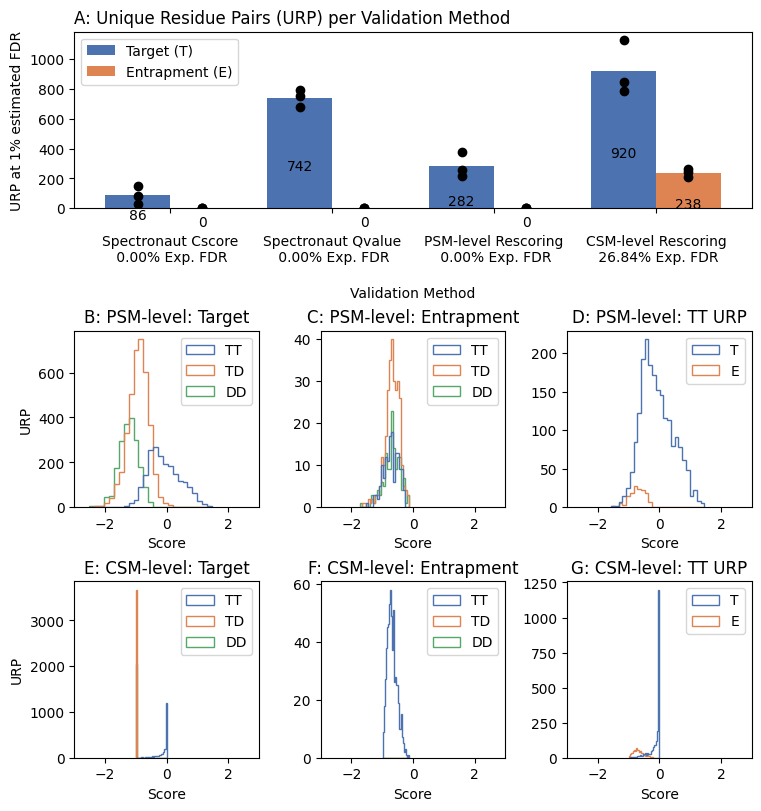

In [69]:
sns.set_palette("deep", 6)

mosaic = """
AAAAAAAAA
BBBCCCDDD
EEEFFFGGG
"""

gridspec_kw = {
    "width_ratios": [1, 1, 1, 1, 1, 1, 1, 1, 1],  # equal width 3 for A, B, C columns
    "height_ratios": [2, 2, 2],
}

fig, axes = plt.subplot_mosaic(
    mosaic, gridspec_kw=gridspec_kw, figsize=(7.5, 8), layout="constrained"
)

plot_comparison(axes["A"])
plot_b(axes["B"])
plot_c(axes["C"])
plot_d(axes["D"])
plot_e(axes["E"])
plot_f(axes["F"])
plot_g(axes["G"])

plt.savefig("plots/figure.svg", dpi=900, transparent=True, bbox_inches="tight")
plt.savefig("plots/figure.eps", dpi=900, transparent=True, bbox_inches="tight")
plt.savefig("plots/figure.png", dpi=900, transparent=True, bbox_inches="tight")
plt.show()